In [1]:
# Clone the dataset directly into Colab
!git clone https://github.com/emanhamed/Houses-dataset.git
!ls "Houses-dataset/Houses Dataset/"

Cloning into 'Houses-dataset'...
remote: Enumerating objects: 2166, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 2166 (delta 0), reused 0 (delta 0), pack-reused 2165 (from 1)
Receiving objects: 100% (2166/2166), 176.26 MiB | 33.41 MiB/s, done.
Resolving deltas: 100% (20/20), done.
100_bathroom.jpg  221_bathroom.jpg  342_bathroom.jpg  463_bathroom.jpg
100_bedroom.jpg   221_bedroom.jpg   342_bedroom.jpg   463_bedroom.jpg
100_frontal.jpg   221_frontal.jpg   342_frontal.jpg   463_frontal.jpg
100_kitchen.jpg   221_kitchen.jpg   342_kitchen.jpg   463_kitchen.jpg
101_bathroom.jpg  222_bathroom.jpg  343_bathroom.jpg  464_bathroom.jpg
101_bedroom.jpg   222_bedroom.jpg   343_bedroom.jpg   464_bedroom.jpg
101_frontal.jpg   222_frontal.jpg   343_frontal.jpg   464_frontal.jpg
101_kitchen.jpg   222_kitchen.jpg   343_kitchen.jpg   464_kitchen.jpg
102_bathroom.jpg  223_bathroom.jpg  344_bathroom.jpg  465_bathroom.jpg
102_bedroom.jpg   223_bedroom.jpg   344_bedroom.jpg   465_bedroom.

In [2]:
import pandas as pd
import numpy as np

# Load the housing info
df_img = pd.read_csv(
    "Houses-dataset/Houses Dataset/HousesInfo.txt",
    header=None,
    sep=' ',
    names=['bedrooms', 'bathrooms', 'area', 'zipcode', 'price']
)

print(f"Shape: {df_img.shape}")
print(f"\nFirst few rows:")
print(df_img.head(10))
print(f"\nPrice stats:")
print(df_img['price'].describe())
print(f"\nMissing values: {df_img.isnull().sum().sum()}")

Shape: (535, 5)

First few rows:
   bedrooms  bathrooms  area  zipcode    price
0         4        4.0  4053    85255   869500
1         4        3.0  3343    36372   865200
2         3        4.0  3923    85266   889000
3         5        5.0  4022    85262   910000
4         3        4.0  4116    85266   971226
5         4        5.0  4581    85266  1249000
6         3        4.0  2544    85262   799000
7         4        5.0  5524    85266  1698000
8         3        4.0  4229    85255  1749000
9         4        5.0  3550    85262  1500000

Price stats:
count    5.350000e+02
mean     5.893628e+05
std      5.090261e+05
min      2.200000e+04
25%      2.492000e+05
50%      5.290000e+05
75%      7.285000e+05
max      5.858000e+06
Name: price, dtype: float64

Missing values: 0


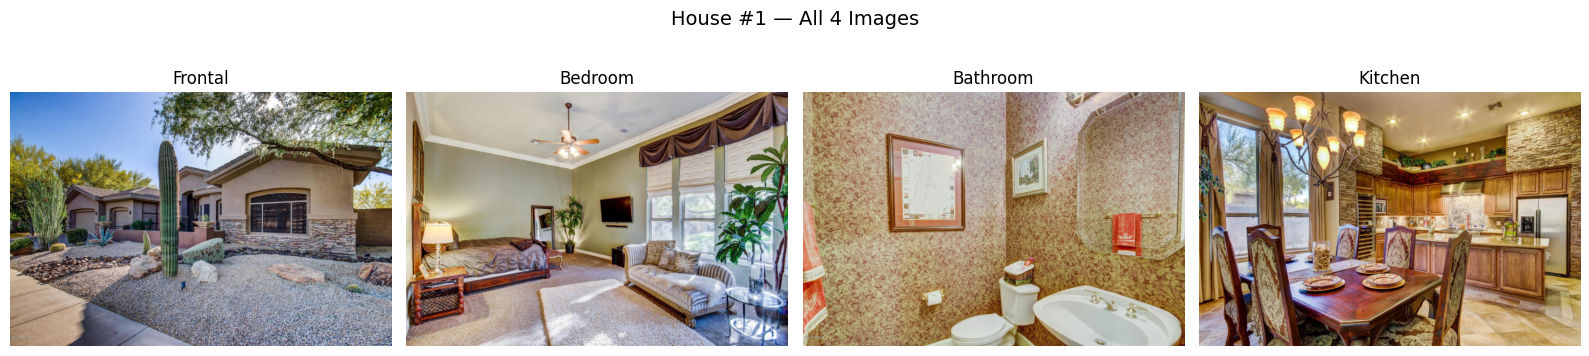

Sample images displayed ✅


In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

img_dir = "Houses-dataset/Houses Dataset/"

# Show sample images for house #1
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
img_types = ['frontal', 'bedroom', 'bathroom', 'kitchen']

for ax, img_type in zip(axes, img_types):
    img_path = os.path.join(img_dir, f"1_{img_type}.jpg")
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(img_type.capitalize())
    ax.axis('off')

plt.suptitle('House #1 — All 4 Images', fontsize=14)
plt.tight_layout()
plt.savefig('sample_house_images.png', dpi=150)
plt.show()
print("Sample images displayed")

In [4]:
!pip install timm -q
print("timm installed")

timm installed


In [5]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

IMG_DIR = "Houses-dataset/Houses Dataset/"
IMG_TYPES = ['frontal', 'bedroom', 'bathroom', 'kitchen']

# ViT-B/16 expects 224x224 images, ImageNet normalization
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class HouseImageDataset(Dataset):
    def __init__(self, indices, prices, img_dir, transform):
        self.indices = indices
        self.prices = prices
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        house_idx = self.indices[idx]
        imgs = []
        for img_type in IMG_TYPES:
            path = os.path.join(self.img_dir, f"{house_idx+1}_{img_type}.jpg")
            img = Image.open(path).convert('RGB')
            imgs.append(self.transform(img))
        # Stack 4 images → average them into one tensor (3, 224, 224)
        img_tensor = torch.stack(imgs).mean(dim=0)
        price = torch.tensor(np.log1p(self.prices[idx]), dtype=torch.float32)
        return img_tensor, price

# Train/val/test split
all_indices = np.arange(len(df_img))
prices = df_img['price'].values

from sklearn.model_selection import train_test_split
idx_train, idx_temp = train_test_split(all_indices, test_size=0.3, random_state=42)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.5, random_state=42)

train_ds = HouseImageDataset(idx_train, prices[idx_train], IMG_DIR, transform)
val_ds   = HouseImageDataset(idx_val,   prices[idx_val],   IMG_DIR, transform)
test_ds  = HouseImageDataset(idx_test,  prices[idx_test],  IMG_DIR, transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print("Image DataLoaders ready")

Train: 374 | Val: 80 | Test: 81
Image DataLoaders ready


In [6]:
import timm

# Load ViT-B/16 pretrained on ImageNet
vit_model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)

# Add regression head for fine-tuning
class ViTRegressor(nn.Module):
    def __init__(self, vit_backbone):
        super().__init__()
        self.backbone = vit_backbone
        self.head = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        features = self.backbone(x)  # (batch, 768)
        return self.head(features).squeeze(1)

img_model = ViTRegressor(vit_model).cuda()
total_params = sum(p.numel() for p in img_model.parameters())
trainable_params = sum(p.numel() for p in img_model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("ViT-B/16 model ready")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Total parameters: 85,995,777
Trainable parameters: 85,995,777
ViT-B/16 model ready


In [7]:
criterion = nn.MSELoss()

# Two param groups: lower LR for pretrained backbone, higher for new head
optimizer = torch.optim.AdamW([
    {'params': img_model.backbone.parameters(), 'lr': 1e-5},
    {'params': img_model.head.parameters(),     'lr': 1e-4}
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

def train_epoch_img(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for imgs, prices in loader:
        imgs, prices = imgs.cuda(), prices.cuda()
        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, prices)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch_img(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for imgs, prices in loader:
            imgs, prices = imgs.cuda(), prices.cuda()
            preds = model(imgs)
            loss = criterion(preds, prices)
            total_loss += loss.item()
    return total_loss / len(loader)

EPOCHS = 30
train_losses, val_losses = [], []
best_val_loss = float('inf')

print("Starting ViT fine-tuning... (this will take ~20-30 mins)")
for epoch in range(EPOCHS):
    train_loss = train_epoch_img(img_model, train_loader, optimizer, criterion)
    val_loss   = eval_epoch_img(img_model, val_loader, criterion)
    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(img_model.state_dict(), 'best_vit_model.pt')

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] Train: {train_loss:.4f} | Val: {val_loss:.4f}")

print("\nViT training complete")

Starting ViT fine-tuning... (this will take ~20-30 mins)
Epoch [5/30] Train: 1.2371 | Val: 0.5549
Epoch [10/30] Train: 1.0219 | Val: 0.7240
Epoch [15/30] Train: 0.9422 | Val: 0.5555
Epoch [20/30] Train: 0.7447 | Val: 0.5905
Epoch [25/30] Train: 0.7493 | Val: 0.4678
Epoch [30/30] Train: 0.7297 | Val: 0.4728

ViT training complete


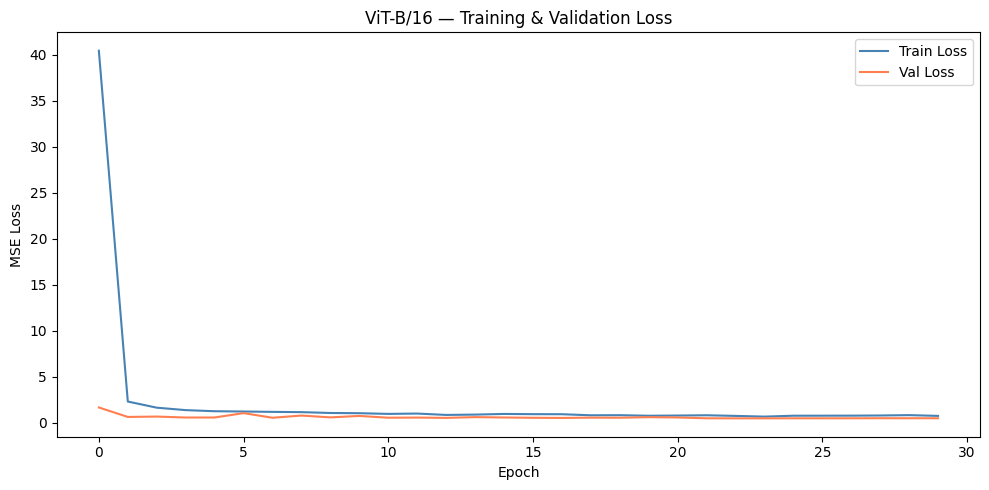

=== Image-Only ViT Results ===
RMSE: $317,932.56
MAE:  $223,730.59
R²:   0.1537


In [8]:
# Plot
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='steelblue')
plt.plot(val_losses, label='Val Loss', color='coral')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('ViT-B/16 — Training & Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig('vit_loss_curve.png', dpi=150)
plt.show()

# Evaluate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

img_model.load_state_dict(torch.load('best_vit_model.pt'))
img_model.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for imgs, prices in test_loader:
        imgs = imgs.cuda()
        preds = img_model(imgs).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(prices.numpy())

all_preds   = np.expm1(np.array(all_preds))
all_targets = np.expm1(np.array(all_targets))

rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
mae  = mean_absolute_error(all_targets, all_preds)
r2   = r2_score(all_targets, all_preds)

print("=== Image-Only ViT Results ===")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAE:  ${mae:,.2f}")
print(f"R²:   {r2:.4f}")